# kNN classifier – Breast Cancer Wisconsin (Diagnostic)

Tässä notebookissa rakennetaan k-nearest neighbors (kNN) -luokittelija UCI:n **Breast Cancer Wisconsin (Diagnostic)** -aineistolle. Työ on jäsennelty CRISP-DM-mallin kuuteen vaiheeseen:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment

# 1. Business Understanding

Tehtävänä on rakentaa binäärinen kNN-luokittelija, joka ennustaa rintakasvaimen diagnoosin:

- **M = malignant (pahanlaatuinen)**
- **B = benign (hyvänlaatuinen)**

Aineiston piirteet on laskettu rintamassasta otetun **fine needle aspirate (FNA)** -näytteen digitoidusta kuvasta ja ne kuvaavat kuvassa näkyvien soluytimien ominaisuuksia.

### Onnistumisen arviointi

Mallia arvioidaan useasta näkökulmasta:

- **Accuracy:** kuinka suuri osa kaikista havainnoista luokitellaan oikein.
- **Precision (M):** kuinka suuri osa malignant-luokkaan ennustetuista on todella malignant.
- **Recall (M):** kuinka suuri osa todellisista malignant-tapauksista tunnistetaan.
- **Confusion matrix:** näyttää oikeiden ja väärien luokitusten määrät erikseen.

Pelkkä accuracy ei ole tässä riittävä mittari. Erityisesti **malignant → benign** -virhe eli false negative on tärkeä havaita, koska tällöin pahanlaatuinen tapaus jää mallilta tunnistamatta.

# 2. Data Understanding

Aineisto haetaan UCI Machine Learning Repositorysta (`id=17`). Aineistossa on:

- **569 havaintoa**
- **30 jatkuvaa numeerista input-muuttujaa**
- **Diagnosis** target-muuttujana
- lisäksi **ID**, joka on tunniste eikä mallin selittävä muuttuja
- UCI:n kuvauksen mukaan aineistossa **ei ole puuttuvia arvoja**

Kymmenen soluytimen perusominaisuutta esiintyy kolmena mittausryhmänä (`1`, `2`, `3`), jolloin input-piirteitä on yhteensä 30.

| Feature family | Merkitys |
|---|---|
| radius | Etäisyyksien keskiarvo keskipisteestä reunaviivan pisteisiin |
| texture | Harmaasävyarvojen keskihajonta |
| perimeter | Soluytimen ympärysmitta |
| area | Soluytimen pinta-ala |
| smoothness | Paikallinen vaihtelu säteen pituuksissa |
| compactness | Tiiviys, määritelty perimeter² / area − 1 |
| concavity | Reunaviivan koverien osien voimakkuus |
| concave points | Koverien osien/pisteiden määrä |
| symmetry | Soluytimen symmetria |
| fractal dimension | “Coastline approximation” -tyyppinen mitta |

Ennen mallintamista tarkastetaan aineiston rakenne, muuttujatyypit, puuttuvat arvot, diagnoosiluokkien jakauma sekä numeeristen muuttujien tunnuslukuja.

In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Fetch dataset
breast_cancer = fetch_ucirepo(id=17)

# Input variables and target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets["Diagnosis"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [2]:
# UCI metadata and variable information
print(breast_cancer.metadata)
display(breast_cancer.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Categorical,None,None,None,no
1,Diagnosis,Target,Categorical,None,None,None,no
2,radius1,Feature,Continuous,None,None,None,no
3,texture1,Feature,Continuous,None,None,None,no
4,perimeter1,Feature,Continuous,None,None,None,no
5,area1,Feature,Continuous,None,None,None,no
6,smoothness1,Feature,Continuous,None,None,None,no
7,compactness1,Feature,Continuous,None,None,None,no
8,concavity1,Feature,Continuous,None,None,None,no
9,concave_points1,Feature,Continuous,None,None,None,no


In [3]:
# Combine features and target for exploratory inspection
df = pd.concat([X, y], axis=1)

display(df.head())
print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDiagnosis distribution:")
display(y.value_counts())
display(y.value_counts(normalize=True).rename("proportion"))

print("\nDescriptive statistics:")
display(X.describe().T)

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M



Data types:


radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
Diagnosis                 str
dtype: object


Missing values:


radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
Diagnosis             0
dtype: int64


Diagnosis distribution:


Diagnosis
B    357
M    212
Name: count, dtype: int64

Diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Data Understanding – tulkinta

Aineiston piirteet ovat numeerisia, mutta niiden mittakaavat poikkeavat selvästi toisistaan: esimerkiksi pinta-alan ja ympärysmitan arvot ovat aivan eri suuruusluokassa kuin smoothness- tai fractal dimension -muuttujat.

# 3. Data Preparation

kNN perustuu havaintojen väliseen etäisyyteen. Jos muuttujat jätetään alkuperäisiin mittakaavoihinsa, suurempia lukuarvoja sisältävät muuttujat voivat hallita etäisyyslaskentaa. Tämän vuoksi input-muuttujat **standardoidaan StandardScalerilla**.

Data jaetaan ensin hold-out-periaatteella:

- **80 % training data**
- **20 % test data**
- `stratify=y` säilyttää diagnoosiluokkien suhteet mahdollisimman samanlaisina molemmissa osissa.
- `random_state=42` tekee jaosta toistettavan.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining class distribution:")
display(y_train.value_counts(normalize=True))

print("Test class distribution:")
display(y_test.value_counts(normalize=True))

Training set: (455, 30)
Test set: (114, 30)

Training class distribution:


Diagnosis
B    0.626374
M    0.373626
Name: proportion, dtype: float64

Test class distribution:


Diagnosis
B    0.631579
M    0.368421
Name: proportion, dtype: float64

In [5]:
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training-data parameters
X_test_scaled = scaler.transform(X_test)

# Optional DataFrames for easier inspection
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled_df.head())

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


### Standardoinnin tarkistus

Training-datan standardoitujen muuttujien keskiarvojen pitäisi olla hyvin lähellä nollaa ja keskihajontojen lähellä yhtä. Testidatan ei tarvitse saada täsmälleen samoja arvoja, koska scaleria ei soviteta siihen erikseen.

In [6]:
scaling_check = pd.DataFrame({
    "train_mean": X_train_scaled_df.mean(),
    "train_std": X_train_scaled_df.std(ddof=0)
})

display(scaling_check.head(10))

,train_mean,train_std
radius1,-1.737316e-16,1.0
texture1,3.904081e-16,1.0
perimeter1,4.704418e-16,1.0
area1,-1.171224e-16,1.0
smoothness1,7.242070e-16,1.0
compactness1,-5.075305e-17,1.0
concavity1,-4.489693e-17,1.0
concave_points1,2.928061e-17,1.0
symmetry1,2.342449e-17,1.0
fractal_dimension1,3.669836e-16,1.0


# 4. Modeling

kNN luokittelee uuden havainnon sen lähimpien naapureiden perusteella. Hyperparametri **k** määrää, kuinka monta lähintä naapuria päätöksessä käytetään.

- Pieni k reagoi voimakkaasti yksittäisiin havaintoihin ja voi olla herkkä kohinalle.
- Suurempi k tasoittaa päätösrajaa, mutta liian suuri k voi hävittää paikallista rakennetta.
- Binäärisessä luokittelussa kokeillaan tässä parittomia k-arvoja, mikä vähentää tasatilanteiden mahdollisuutta.

In [7]:
k_values = list(range(1, 20, 2))
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred_k = model.predict(X_test_scaled)

    results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, y_pred_k),
        "precision_M": precision_score(y_test, y_pred_k, pos_label="M"),
        "recall_M": recall_score(y_test, y_pred_k, pos_label="M")
    })

results_df = pd.DataFrame(results)
display(results_df.round({
    "accuracy": 3,
    "precision_M": 3,
    "recall_M": 3
}))

,k,accuracy,precision_M,recall_M
0,1,0.930,0.925,0.881
1,3,0.939,0.973,0.857
2,5,0.956,0.974,0.905
3,7,0.956,0.974,0.905
4,9,0.947,0.974,0.881
5,11,0.947,0.974,0.881
6,13,0.947,0.974,0.881
7,15,0.947,0.974,0.881
8,17,0.939,0.973,0.857
9,19,0.939,0.973,0.857


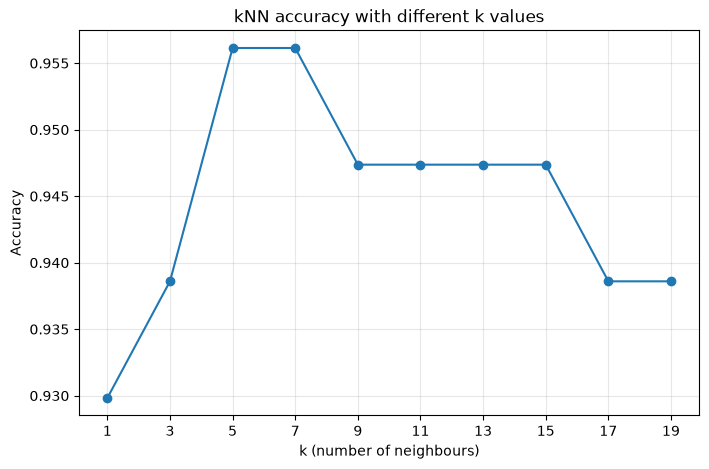

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy"], marker="o")
plt.xlabel("k (number of neighbours)")
plt.ylabel("Accuracy")
plt.title("kNN accuracy with different k values")
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.show()

### k-arvon valinnan tulkinta

Alla valitaan kokeilluista vaihtoehdoista korkean accuracyn antava k. Jos useampi k saa saman accuracyn, valitaan niistä se, jolla malignant-recall on paras ja tämän jälkeen pienempi k.

In [9]:
best_row = (
    results_df
    .sort_values(
        ["accuracy", "recall_M", "k"],
        ascending=[False, False, True]
    )
    .iloc[0]
)

best_k = int(best_row["k"])
print("Selected k:", best_k)
print(best_row)

Selected k: 5
k              5.000000
accuracy       0.956140
precision_M    0.974359
recall_M       0.904762
Name: 2, dtype: float64


# 5. Evaluation

Valittu malli koulutetaan training-datalla ja arvioidaan hold-out-testidatalla. Raportoidaan data ja mallintoiminta:

- confusion matrix
- accuracy
- precision
- recall

Lisäksi näytetään F1-score ja koko classification report, jotta molempien luokkien käyttäytyminen näkyy.

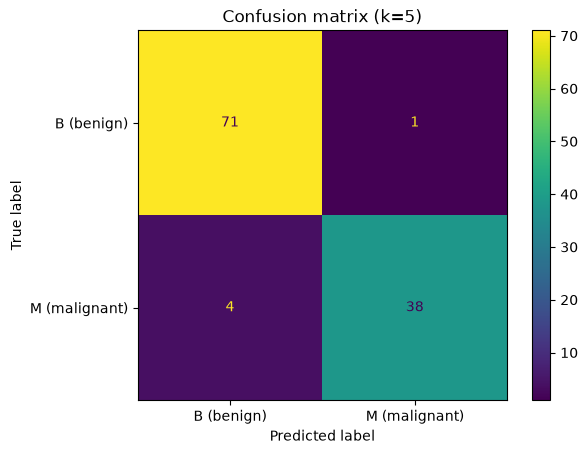

In [10]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)
y_pred = final_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred, labels=["B", "M"])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["B (benign)", "M (malignant)"]
)
disp.plot()
plt.title(f"Confusion matrix (k={best_k})")
plt.show()

In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision_m = precision_score(y_test, y_pred, pos_label="M")
recall_m = recall_score(y_test, y_pred, pos_label="M")
f1_m = f1_score(y_test, y_pred, pos_label="M")

print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision M: {precision_m:.3f}")
print(f"Recall M:    {recall_m:.3f}")
print(f"F1-score M:  {f1_m:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy:    0.956
Precision M: 0.974
Recall M:    0.905
F1-score M:  0.938

Classification report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [12]:
# Confusion matrix breakdown with B as negative class and M as positive class
tn, fp, fn, tp = cm.ravel()

print("True negatives  (B -> B):", tn)
print("False positives (B -> M):", fp)
print("False negatives (M -> B):", fn)
print("True positives  (M -> M):", tp)

True negatives  (B -> B): 71
False positives (B -> M): 1
False negatives (M -> B): 4
True positives  (M -> M): 38


### Tulosten tulkinta

Confusion matrixia tulkitaan tässä siten, että **malignant (M) on positiivinen luokka**:

- **TP:** malignant ennustettiin malignantiksi.
- **TN:** benign ennustettiin benigniksi.
- **FP:** benign ennustettiin malignantiksi.
- **FN:** malignant ennustettiin benigniksi.

Erityisesti FN-luku on tärkeä, koska se kuvaa pahanlaatuisia tapauksia, jotka malli jätti tunnistamatta.

# 6. Deployment

Mallia voitaisiin teknisesti käyttää uusien havaintojen luokitteluun, mutta käyttö vaatisi vähintään seuraavan prosessin:

1. Uudesta FNA-näytteestä täytyy muodostaa täsmälleen samat 30 input-piirrettä.
2. Piirteiden järjestyksen ja merkityksen täytyy vastata training-dataa.
3. Uudet arvot täytyy standardoida **samalla training-datasta sovitetulla scalerilla**.
4. Standardoidut arvot annetaan koulutetulle kNN-mallille.
5. Mallin ennuste ja sen epävarmuus/rajoitteet täytyy huomioida käyttökontekstissa.

### Rajoitteet

- Aineisto on melko pieni (569 havaintoa).
- Yksi hold-out-jako ei riitä osoittamaan mallin yleistyvyyttä.
- kNN:n ennustaminen voi muuttua raskaaksi, jos training-aineisto kasvaa paljon, koska uusia havaintoja verrataan tallennettuihin training-havaintoihin.
- Hyperparametrin valinta olisi luotettavampaa cross-validationilla.
- Todellista kliinistä käyttöä varten tarvittaisiin huomattavasti laajempi ja riippumaton validointi.

### Johtopäätös

Standardointi on olennainen osa prosessia, koska kNN perustuu etäisyyksiin. Mallin onnistumista ei tule arvioida vain accuracyn avulla: erityisesti malignant-luokan recall ja false negative -tapaukset ovat keskeisiä.

Jatkokehityksessä tuloksia voisi vahvistaa esimerkiksi cross-validationilla, erillisellä hyperparametrien optimoinnilla ja vertaamalla kNN:ää muihin luokittelualgoritmeihin.